# project 1: differential expression analysis (transcriptomics)

In [1]:
import numpy as np 
## for data manipulation

import csv
## csv reader

import random
## random number generator 

import matplotlib.pyplot as plt
## part of matplotlib that deals with plotting stuff

from scipy.stats import ks_2samp 
## tool from scipy. ks_2samp is the Kolmogorov-Smirmov test. compares two datasets to see if they come from the same distribution.
## used here to compare healthy tissue vs IPF tissue

import seaborn as sns
## makes plotting stuff by matplotlib cleaner ig

data is used from [GEO](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE150910).
gene names are listed using `genes`, expression measurements are listed as `data`

In [2]:
genes = []
data = []

with open ("GSE150910_gene-level_count_file.csv") as csvfile:
    reader = csv.reader(csvfile, delimiter=",") ## delimiter is something that seperates values
    for row in reader:

        genes.append(row[0])
        data.append(row[1:])
        ## append: add something to a list


In [3]:
samples = data [0]
data = data [1:]
genes = genes [1:]

moving everything to numpy arrays

In [4]:
data = np.array(data).astype(float)
genes = np.array(genes)
samples = np.array(samples)

In [5]:
print(genes.shape)
print(data.shape)
print(samples.shape)

(18838,)
(18838, 288)
(288,)


^ this step shows how big my array is.
18k+ genes, 288 samples, data is just the entire thing

In [6]:
print("genes")
print(genes[0:2])

print("samples")
print(samples[0:2])

print("data")
print(data[0:2,0:2])

genes
['TSPAN6' 'TNMD']
samples
['chp_26' 'chp_31']
data
[[1361.  993.]
 [   5.   13.]]


In [7]:
labels = []

for i in range(len(samples)):
    tmp = samples[i].split("_")
    labels.append(tmp[0])
    
labels = np.array(labels)

In [8]:
print(labels[0:5])

print(np.unique(labels))

['chp' 'chp' 'chp' 'chp' 'chp']
['chp' 'control' 'ipf']


CHP = chronic hypersensitivity pneumonitis, control, and IPF = idiopathic pulmonary fibrosis

In [9]:
data = data[:  ,labels != "chp"]
samples = samples[labels != "chp"]
labels = labels[labels != "chp"]

In [10]:
print(data.shape)
print(samples.shape)
print(labels.shape)

(18838, 206)
(206,)
(206,)


#### info on sequencing depth: using the flashlight analogy

there are two rooms, A and B. i look at these rooms using two different torches through a keyhole. for A, i use a powerful torch and for B i use a weak torch. the powerful torch captures 1k details while the other one captures 100 details. now lets say for A i count 500 TSPAN6 genes but for B i count 50 TSPAN6. if i just looked at the raw numbers (500 vs 50) i would think that sample A has 10 times more gene activity, which may not be the case. so to make the comparison fair, we normalize the data (if i had seen 1,000,000 molecules in every sample, how many of them would be this specific gene?) 

$
CPM = \left(\frac{\text{gene count}}{\text{total counts in sample}} \right) ×  1,000,000
$

In [11]:
for j in range (data.shape[1]): ## rows, columns, shape 1 means column. so look at at the columns/genes. j acts as a pointer here.
    column_sum = sum(data[:,j]) 

    data[:,j] / column_sum * 1000000

eliminating genes that are in very low expression in both conditions:

python moves to the first gene i.e. TSPAN6, looks at the value of all control patients, calculates the average for that one gene. then moves to the next gene and does it again.

In [12]:
mean_CPM_control = data[:,labels == "control"].mean(axis=1) ## only healthy patients. axis 1: python moves horizontally across the rows
mean_CPM_ipf = data[:, labels == "ipf"].mean(axis=1) ## only ipf patients

to_keep = (mean_CPM_ipf >= 5) | (mean_CPM_control >= 5)

data = data[to_keep,:]
genes = genes[to_keep]

print(data.shape)
print(len(genes))

(16465, 206)
16465


Kolmogorov-Smirnov test: KS test is a shape checker. here it's going to check if gene 0 is involved in the disease compared to the control.

null hypothesis, $H_{0}$= there is no difference in the expression of this gene between healthy and IPF patients.

In [13]:
control = data [0, labels == "control"]
ipf = data [0, labels == "ipf"]

In [14]:
print(control.shape)
print(ipf.shape)

(103,)
(103,)


In [15]:
ks_statistic, p_value = ks_2samp(control, ipf)

print(f"ks_statistic: {ks_statistic}") 
print(f"p_value:{p_value}")

ks_statistic: 0.34951456310679613
p_value:5.592730604442978e-06


p value is < 0.05, so null hypothesis is rejected

hence, the gene 0 IS behaving differently in IPF lungs compared to healthy lungs.

KS statistics: 0.35
this score can go from 0 to 1. 0.35 means that is a significant gap or shift between the gene expression of the two groups.

**LOG FOLD CHANGE**: the KS test told us that if there's a difference or not. LFC tells us what kind of difference it is. 

(are the sick cells overproducing this gene, or are they missing it?) 

$\frac{\text{Expression Mean (IPF)}}{\text{Expression Mean (Control)}}$ is a way to ask "how many times bigger?" 

if healthy people have 10 and sick 40, LFC is 4. (4x higher)

if healthy people have 10 and sick 5, LFC is 0.5. (half)

we're using $\log_2$ to center everything around 0. 

$\log_2(1) = 0$: no change (ipf and control are the same).

$\log_2(2) = 1$: exactly double (upregulated: gene expression is more than usual)

$\log_2(0.5) = -1$: exactly half (downregulated: gene expression is less than normal)

using ``epsilon`` to ensure that the smallest a number can ever be is 1. there might be some mean that is zero in some samples, and if we divide by zero then boom.

In [16]:
epsilon = 1 

control_mean = np.mean(control)
ipf_mean = np.mean(ipf)

## calculating FC (fold change)

FC = (ipf_mean + epsilon) / (control_mean + epsilon) 
log2_FC = np.log2(FC) 

print(log2_FC)

0.6272326221582492


next doing this for all genes and saving p and log2_FC values for each

In [17]:
p_values = []
log2_FCs = []  
epsilon = 1

for i in range(data.shape[0]):
    control = data[i, labels == "control"]
    ipf = data[i, labels == "ipf"]

    ## KS test
    ks_statistic, p_val = ks_2samp(control, ipf)
    p_values.append(p_val)

    ## calculate means
    control_mean = np.mean(control)
    ipf_mean = np.mean(ipf)

    ## Log2 FC
    FC = (ipf_mean + epsilon) / (control_mean + epsilon)
    current_log2_FC = np.log2(FC) 
    
    log2_FCs.append(current_log2_FC)

p_values = np.array(p_values)
log2_FCs = np.array(log2_FCs)

**Bonferroni correction**

lets say i have a magic coin that always lands on heads. imagine there's 1k people in a room and hypothetically 1 person gets 10 heads in a row. if i just look at that one person and ignore that other 999, i might wrongly conclude that they actually have a magic coin. 

enter Bonferroni correction. i used a p value of 0.05 (5% chance of being wrong). 5% of 12,450 is 622. this means 622 genes could show up as "significant" even if they have absolutely nothing to do with IPF.

$$\text{corrected p value} = \text{original p value} \times \text{number of tests}$$

$$\text{new threshold} = \frac{0.05}{12450} = 0.000004$$

In [18]:
p_values_bonf = p_values * len(genes)

to be a differently expressed gene (DEG) in this study, a gene has to pass through 2 locks:

1) p value: ``p_values_bonf <= 0.05``
2) log 2 FC: ``np.abs(log2_FCs) >= 2`` ensures that the change is big enough to actually matter to a human being. np.abs just means absolute value, because we care about the genes that went UP (+2, +3, +4) AND the genes that went down (-2, -3, -4)

In [19]:
to_keep = (p_values_bonf <= 0.05) & (np.abs(log2_FCs) >= 2)

sig_genes = genes[to_keep] 
sig_log2_FCs = log2_FCs[to_keep] 
sig_p_values_bonf = p_values_bonf[to_keep]
sig_data = data[to_keep, :]

In [20]:
print(f"number of DEGs: {len(sig_genes)}")
print(f"total number of genes: {len(genes)}")
print(f"DEG percentage: {len(sig_genes) / len(genes) * 100}")
print()
print()
print(f"number of upregulated DEGs: {np.sum(sig_log2_FCs>0)}")
print(f"number of downregulated DEGs: {np.sum(sig_log2_FCs<0)}")

number of DEGs: 174
total number of genes: 16465
DEG percentage: 1.0567871242028546


number of upregulated DEGs: 127
number of downregulated DEGs: 47


In [21]:
for i in range(len(sig_genes)):
    if sig_log2_FCs[i] > 0:
        print(sig_genes[i])

MEOX1
USH1C
PROM1
DPEP1
CLCA4
CYP24A1
CDH3
COL17A1
TP63
ATP12A
FAT2
SLC4A11
MMP11
DERL3
VSIG1
CD79A
SLC5A5
COMP
TMEM59L
COL1A1
PDE10A
COL7A1
UPK1B
OTX1
MUC5B
TP53AIP1
IL13RA2
COL10A1
CXCL6
BPIFB1
TNS4
FCRLA
POSTN
FAM83F
ERN2
DSC3
BAAT
TFAP2A
NXPE4
TMPRSS4
MMP13
STRA6
GPR87
ADAMTS14
GCNT3
ADAMTS18
PADI3
PADI1
FCRL5
MUC4
ADAMTS16
SHISAL2B
FAM83A
PLEKHS1
SYT8
MMP3
ADGRF4
THY1
PROM2
CXCL13
FUT6
MS4A1
TNFRSF13C
CILP2
SCGB3A1
AQP5
PGLYRP4
CTHRC1
CLDN2
TSHR
MOGAT2
SCG5
GREM1
UGT1A6
LY6D
KLK6
PNOC
COL3A1
SPRR1A
BNC1
DRD5
SLN
CST1
MZB1
HS6ST2
KRT15
KRT13
ECEL1
GAP43
SYT12
TEX26
CALML3
DNAJC22
LGALS7B
B3GNT3
DEFB124
MUC16
FDCSP
ALDH1A3
LRRC26
WT1
IFNE
CYP27C1
KRT14
COL14A1
PLA2G2A
GJB5
S100A2
SERPINB13
BPIFA1
PAX9
IGFL2
LGALS7
KRT6A
SERPINB4
DIO2
KRTAP2-3
MUC5AC
TMEM229A
SHISA8
SMIM31
IGLL5
TUBB3
AC136428.1
MSMB
PRSS2
VSIG10L2


printed all the upregulated DEG genes to have a look at!

In [22]:
for i in range(len(sig_genes)):
    if sig_log2_FCs[i] < 0:
        print(sig_genes[i])

HSD17B6
LAMP3
SLCO1A2
CRTAC1
RS1
PRX
LIM2
SLC6A4
APOA5
SEMA5A
BTNL8
RBP2
VIPR1
ADRA1A
MYRF
HMGCS2
SLC14A1
PNMT
FCN3
GGTLC1
KLRF1
OLAH
FAM167A
ADCY8
SNX22
ITLN2
ALPP
DEFA4
BTNL9
MS4A15
CA4
KIR3DL1
HTR3C
GRM8
MAP3K15
RTKN2
RGS9BP
CCK
HELT
KLRG2
AGER
LY6G6F
DEFA1
DEFA1B
AL096711.2
LY6G6E
MYZAP


and these are the downregulated genes!

In [23]:
import csv

## saving upregulated files

output_file_up = "upregulated_DEGs.csv" 

with open(output_file_up, mode = 'w', newline = '') as file:
    writer = csv.writer(file) 
    writer.writerow(["gene", "p_value", "log2_FC"])
    for i in range(len(sig_genes)):
        if sig_log2_FCs[i] > 0:
            writer.writerow([sig_genes[i], sig_p_values_bonf[i], sig_log2_FCs[i]])

## saving downregulated files 

output_file_down = "downregulated_DEGs.csv"
# Fixed newline='' below (no space!)
with open(output_file_down, mode = 'w', newline = '') as file:
    writer = csv.writer(file) 
    writer.writerow(["gene", "p_value", "log2_FC"])
    for i in range(len(sig_genes)):
        if sig_log2_FCs[i] < 0:
            writer.writerow([sig_genes[i], sig_p_values_bonf[i], sig_log2_FCs[i]])

#### tried doing a volcano plot for this

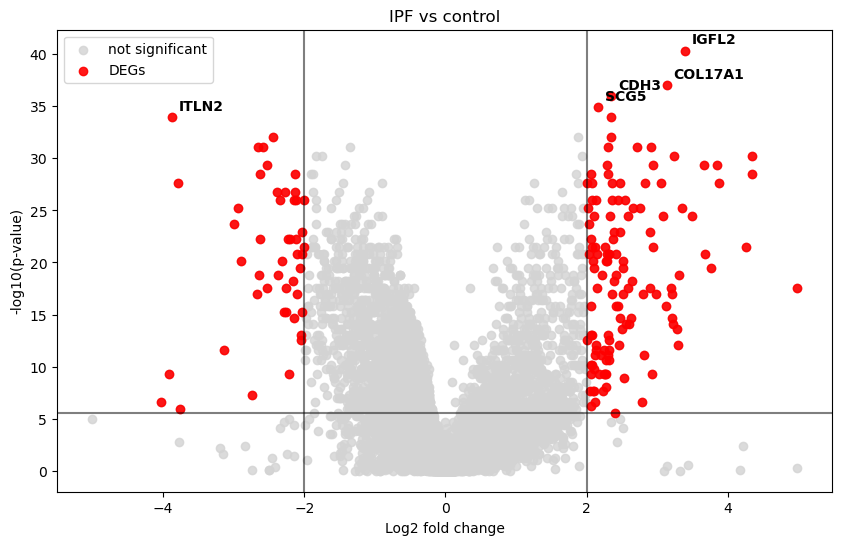

In [24]:
## we use raw p values here not Bonferroni ones, because log scale handles smaller numbers better visually
neg_log_p = -np.log10(p_values) 

plt.figure(figsize=(10, 6)) 

## plotting all genes in gray first :P
plt.scatter(log2_FCs, neg_log_p, color = "lightgrey", alpha = 0.8, label = "not significant") 

## highlighting DEGs
plt.scatter(log2_FCs[to_keep], neg_log_p[to_keep], color = "red", alpha = 0.9, label = "DEGs")

## highlighting top 5 DEGs
top_5_DEGs = np.argsort(p_values)[:5] 

for i in top_5_DEGs:
    plt.annotate(
        genes[i],                     ## name of the gene
        (log2_FCs[i], neg_log_p[i]),  ## x,y coordinates
        textcoords="offset points",   ## positioning the text
        xytext=(5, 5),                ## move text 5 points right and 5 points up
        ha='left',                    ## horizontal alignment
        fontsize=10,
        fontweight='bold'
    )
        

plt.axhline(-np.log10(0.05/len(p_values)), color = "black", linestyle = "-", alpha=0.5) # bonferroni line
plt.axvline(2, color = "black", linestyle = "-", alpha = 0.5)  # +2 fold change
plt.axvline(-2, color = "black", linestyle = "-", alpha = 0.5) # -2 fold change

plt.xlabel("Log2 fold change")
plt.ylabel("-log10(p-value)") 
plt.title("IPF vs control")
plt.legend()

plt.savefig("volcano.pdf")
plt.show()

successful ig 🔥🔥

#### now a heatmap

In [25]:
sig_data_log2fc = np.zeros_like(sig_data)

epsilon = 1

for i in range(len(sig_genes)):
    control_mean = np.mean(sig_data[i,labels == "control"]) ## looks at 206 people, marks true for healthy people and false for patients

    sig_data_log2fc[i,:] = np.log2((sig_data[i,:] + epsilon) / (control_mean + epsilon))

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


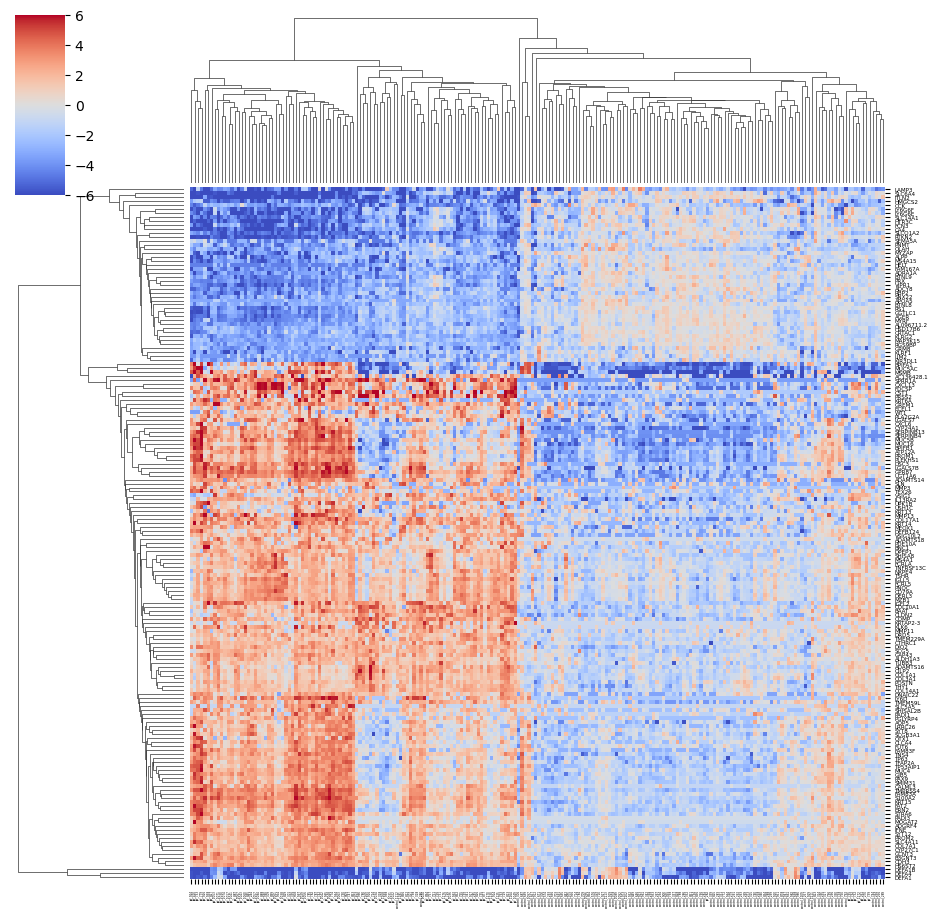

In [26]:
sns_plot = sns.clustermap(
    sig_data_log2fc, 
    xticklabels=samples, 
    yticklabels=sig_genes, 
    cmap="coolwarm", 
    vmin=-6, 
    vmax=6
)

sns_plot.ax_heatmap.set_xticklabels(sns_plot.ax_heatmap.get_xmajorticklabels(), fontsize=2)
sns_plot.ax_heatmap.set_yticklabels(sns_plot.ax_heatmap.get_ymajorticklabels(), fontsize=4)


sns_plot.savefig("heatmap.pdf")

plt.show()